In [1]:
import numpy as np

import grover
import utils
import entropy
import quantum_random_walk

# Grover algorithm entropy analysis

In [2]:
shots=10240
qubits=8 # use 10 with caution
marked_state = 0b111  # target state as integer (|111> = 7)

In [3]:
# We test with applying Grover operator G k times and measure success probability
for k in range(1, 11):
    qc = grover.construct_grover(qubits, k, marked_state)
    counts = utils.measure(qc, shots,skip_qubits=[qubits])

    marked_bitstring = format(marked_state, f'0{qubits}b')
    success_counts = counts.get(marked_bitstring, 0)
    probability = success_counts / shots
    theta = np.arcsin(np.sqrt(1/2**qubits))
    prediction = np.sin((2*k+1)*theta)**2
    print(f"k={k:2d}  success state probability: {probability:.5f}   theoretical prediction: {prediction:.5f}")

k= 1  success state probability: 0.03398   theoretical prediction: 0.03479
k= 2  success state probability: 0.09619   theoretical prediction: 0.09464
k= 3  success state probability: 0.17695   theoretical prediction: 0.17972
k= 4  success state probability: 0.27969   theoretical prediction: 0.28474
k= 5  success state probability: 0.41152   theoretical prediction: 0.40317
k= 6  success state probability: 0.52490   theoretical prediction: 0.52762
k= 7  success state probability: 0.64990   theoretical prediction: 0.65035
k= 8  success state probability: 0.76729   theoretical prediction: 0.76372
k= 9  success state probability: 0.86416   theoretical prediction: 0.86068
k=10  success state probability: 0.93486   theoretical prediction: 0.93518


In [4]:
k_optimal = grover.optimal_iterations(qubits) 
print(f"optimal amount of repetitions: {k_optimal}")

qc = grover.construct_grover(qubits, k_optimal, marked_state=marked_state)
counts = utils.measure(qc, shots, skip_qubits=[qubits])

marked_bitstring = format(marked_state, f'0{qubits}b')
success_counts = counts.get(marked_bitstring, 0)
probability = success_counts / shots
theta = np.arcsin(np.sqrt(1/2**qubits))
prediction = np.sin((2*k_optimal+1)*theta)**2
print(f"k={k_optimal:2d}  success state probability: {probability:.5f}   theoretical prediction: {prediction:.5f}")


optimal amount of repetitions: 12
k=12  success state probability: 0.99990   theoretical prediction: 0.99995


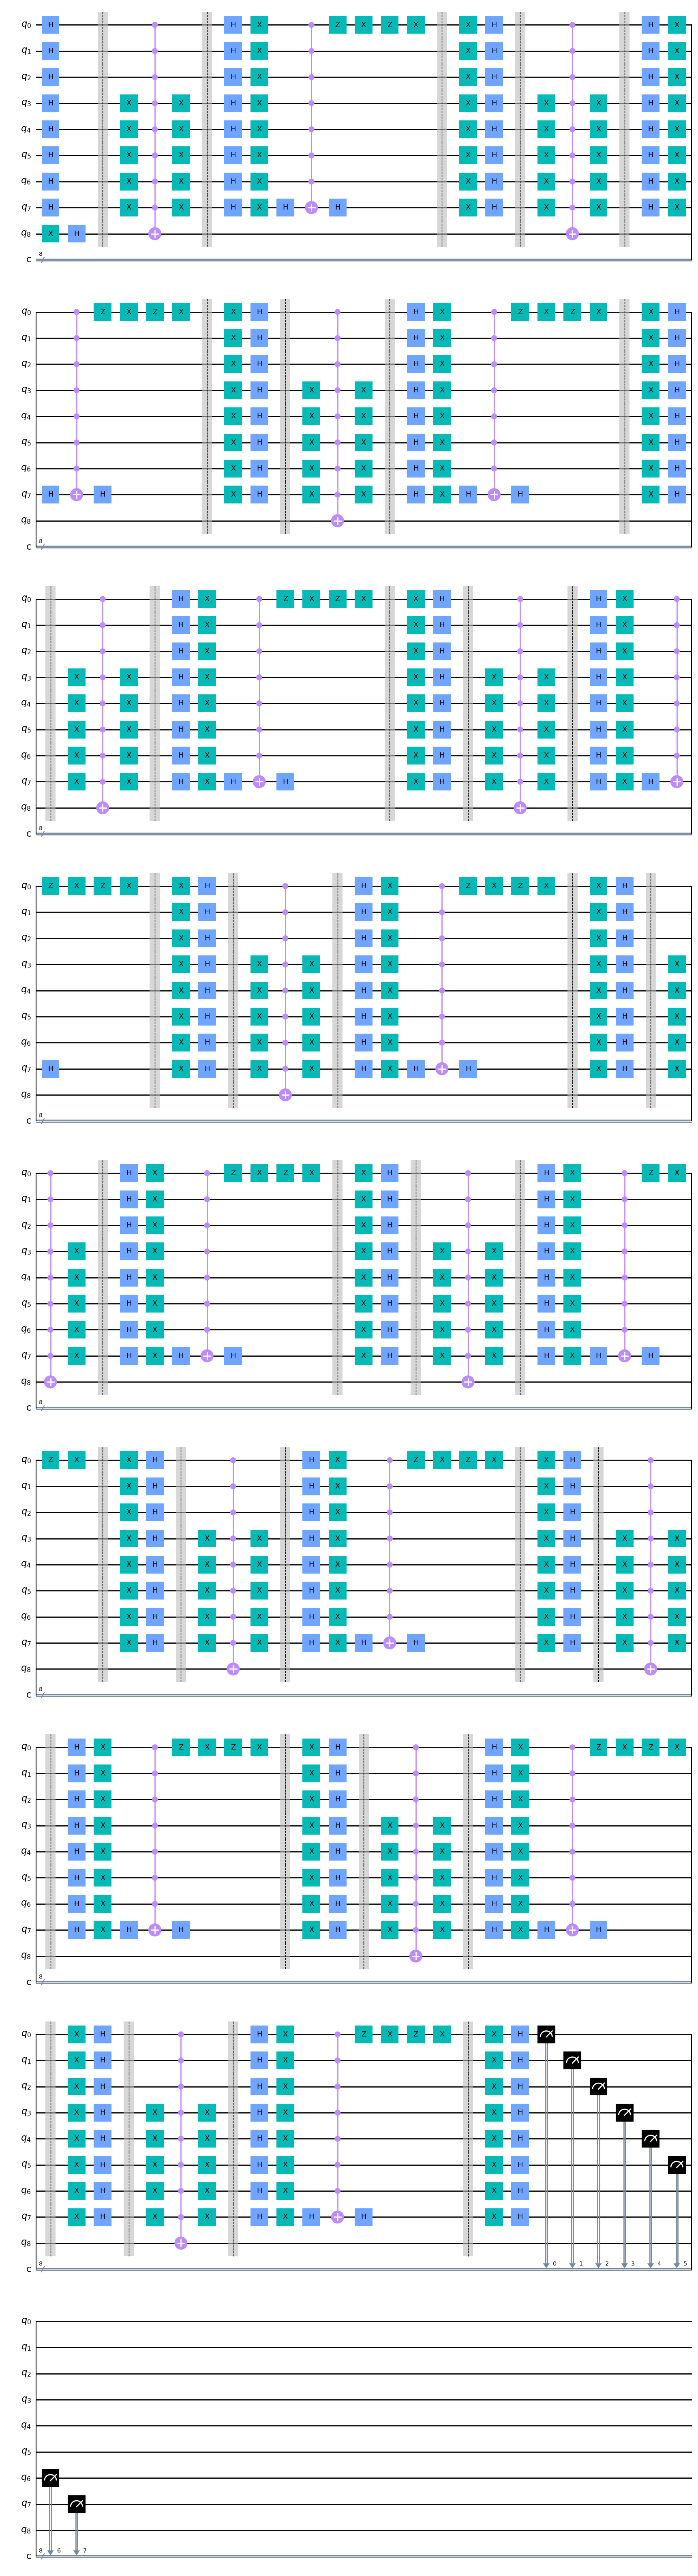

In [5]:
qc.draw(output="mpl",style="clifford")

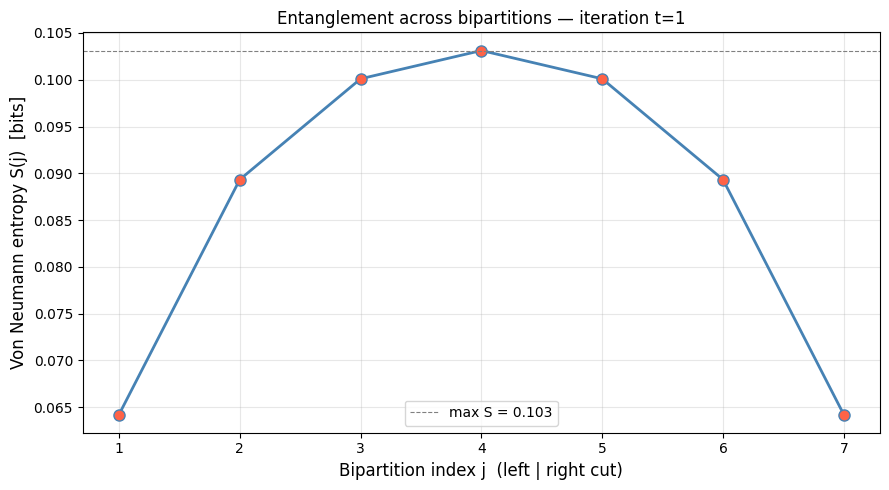

In [6]:
t_fixed = 1
qc = grover.construct_grover(qubits, k=t_fixed, marked_state=marked_state)
entropy.plot_entropy_vs_j(qc, n=qubits, t= t_fixed)

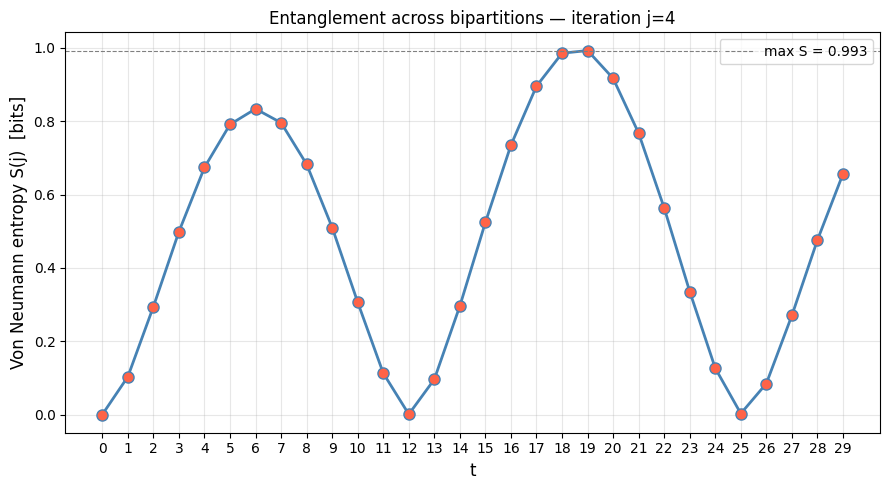

In [7]:
grover_lambda = lambda t: grover.construct_grover(qubits, t, marked_state=marked_state)
entropy.plot_entropy_vs_t(grover_lambda, n=qubits, j=qubits // 2, t_max=30)

n= 2  j=1  S=0.00000
n= 3  j=1  S=0.19794
n= 4  j=2  S=0.90234
n= 5  j=2  S=0.00685
n= 6  j=3  S=0.51978
n= 7  j=3  S=0.76242
n= 8  j=4  S=0.67392
n= 9  j=4  S=0.48063
n=10  j=5  S=0.31261
n=11  j=5  S=0.19050
n=12  j=6  S=0.11236


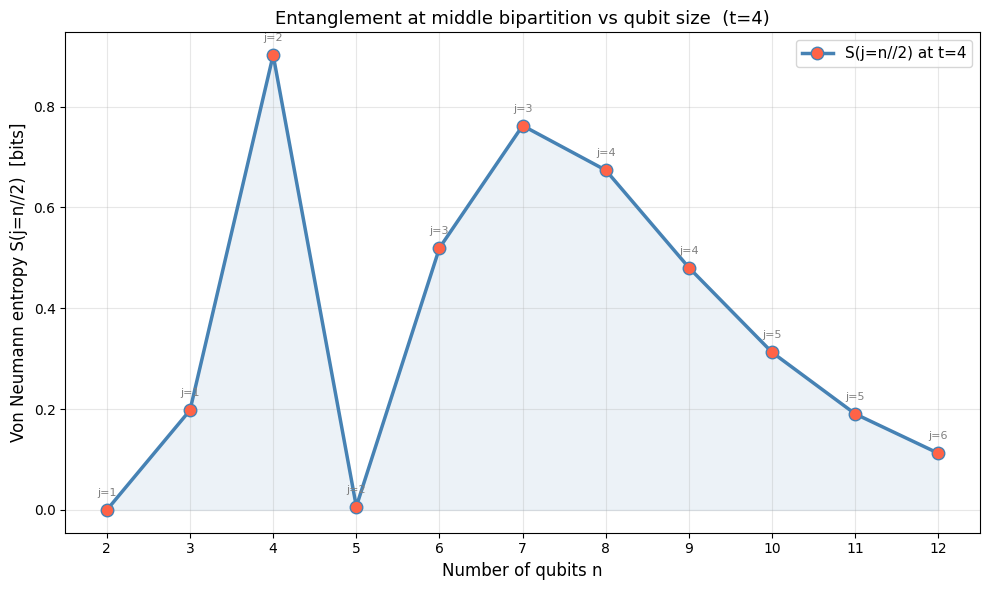

In [8]:
marked_state = 7
qubit_sizes  = list(range(2, 13))

# Single t
t_fixed  = 4
builder  = lambda n: grover.construct_grover(n, t_fixed, marked_state)
entropy.plot_entropy_vs_n(qubit_sizes, builder, t_fixed)


n= 2  j=1  S=0.00000
n= 3  j=1  S=0.28344
n= 4  j=2  S=0.42502
n= 5  j=2  S=0.35592
n= 6  j=3  S=0.26031
n= 7  j=3  S=0.16689
n= 8  j=4  S=0.10312
n= 9  j=4  S=0.06042
n=10  j=5  S=0.03482
n=11  j=5  S=0.01954
n=12  j=6  S=0.01086
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.92453
n= 4  j=2  S=0.17037
n= 5  j=2  S=0.32215
n= 6  j=3  S=0.69045
n= 7  j=3  S=0.65961
n= 8  j=4  S=0.49876
n= 9  j=4  S=0.32946
n=10  j=5  S=0.20520
n=11  j=5  S=0.12168
n=12  j=6  S=0.07045
n= 2  j=1  S=1.00000
n= 3  j=1  S=0.27825
n= 4  j=2  S=0.80715
n= 5  j=2  S=0.48488
n= 6  j=3  S=0.17773
n= 7  j=3  S=0.71476
n= 8  j=4  S=0.79118
n= 9  j=4  S=0.62029
n=10  j=5  S=0.42380
n=11  j=5  S=0.26588
n=12  j=6  S=0.15978
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.15579
n= 4  j=2  S=0.78082
n= 5  j=2  S=0.41887
n= 6  j=3  S=0.88693
n= 7  j=3  S=0.36330
n= 8  j=4  S=0.30619
n= 9  j=4  S=0.83728
n=10  j=5  S=0.85697
n=11  j=5  S=0.65266
n=12  j=6  S=0.43737


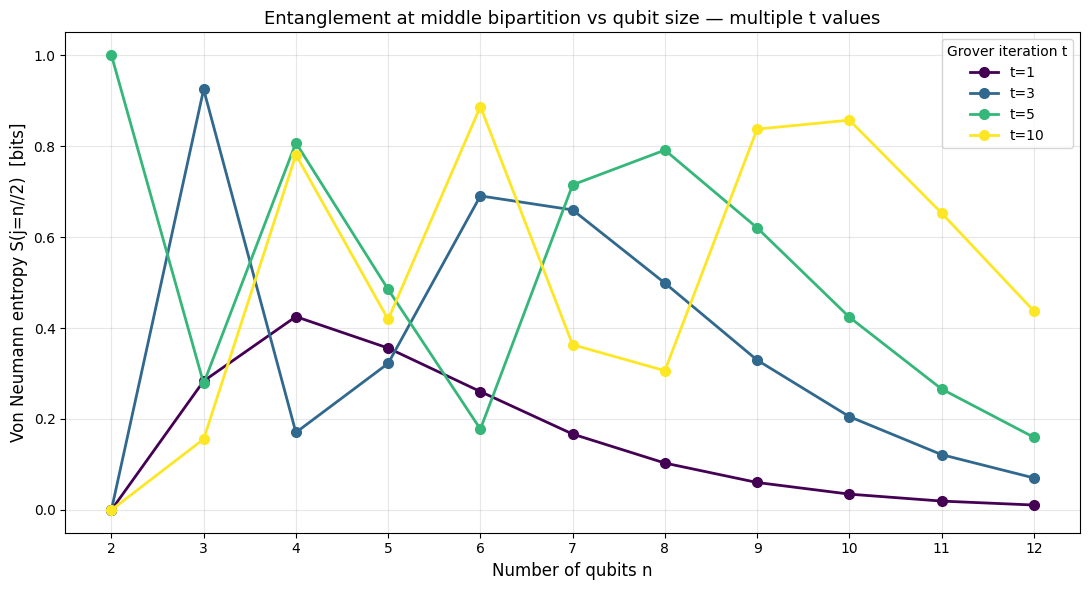

In [9]:
# Multiple t values — build one lambda per t
t_values      = [1, 3, 5, 10]
builder_per_t = [(t, lambda n, t=t: grover.construct_grover(n, t, marked_state))
                 for t in t_values]
entropy.plot_entropy_vs_n_multi_t(qubit_sizes, builder_per_t)

# Quantum random walk entropy analysis

In [10]:
shots=1024
qubits = 7
t=50
shots = 1024

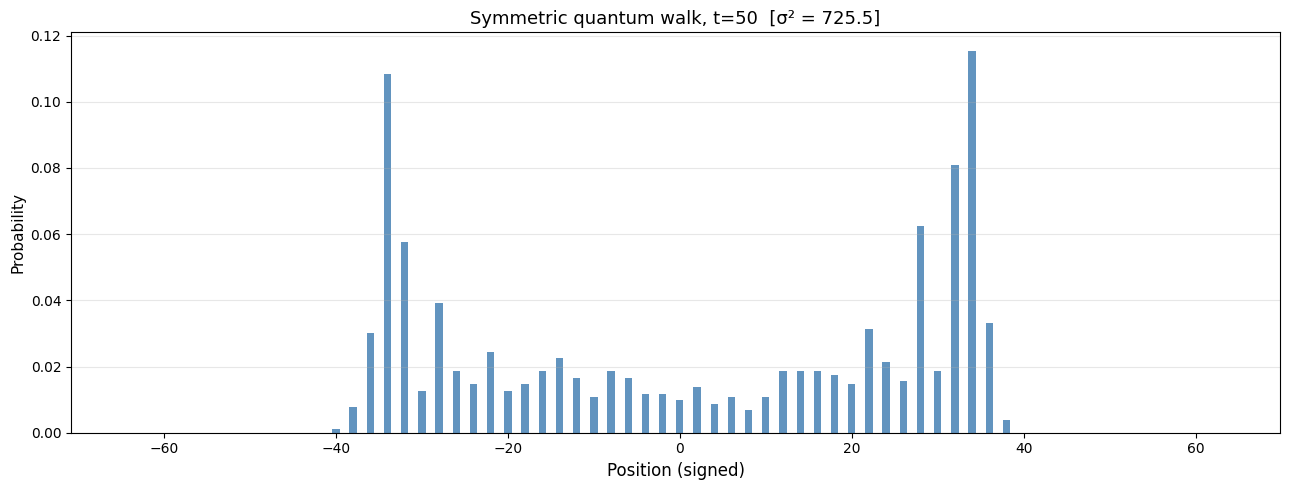

In [11]:
quantum_random_walk.plot_walk(n_position_qubits=qubits, steps=t, shots = shots)

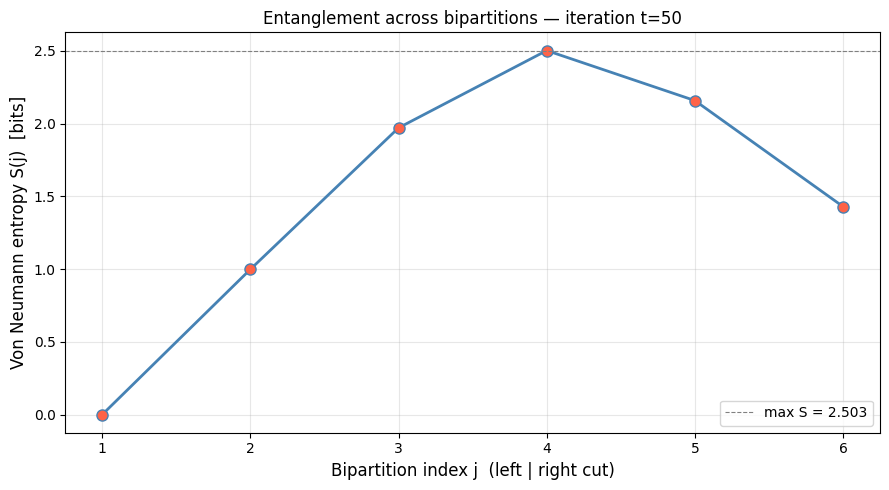

In [12]:
t_fixed = 50
qc = quantum_random_walk.construct_walk(qubits, t_fixed)
entropy.plot_entropy_vs_j(qc, n=qubits, t= t_fixed)

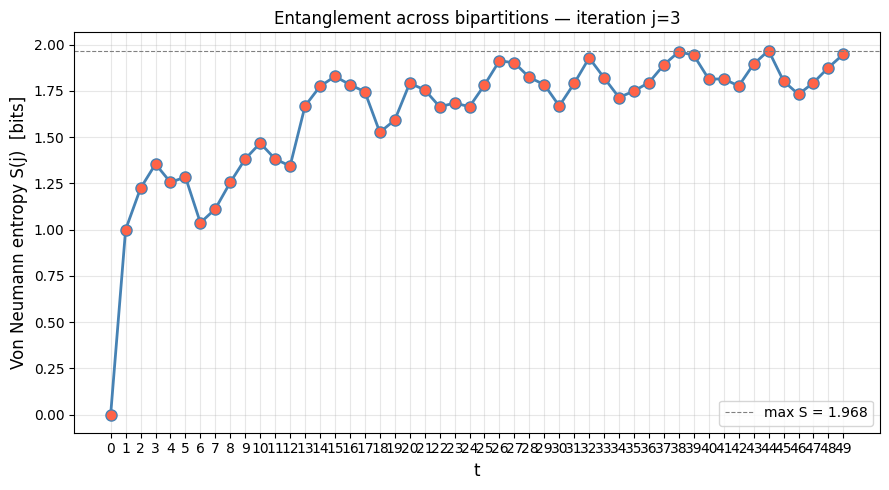

In [13]:
quantum_walk_lambda = lambda t: quantum_random_walk.construct_walk(qubits, t)
entropy.plot_entropy_vs_t(quantum_walk_lambda, n=qubits, j=qubits // 2, t_max=50)

n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.79885
n= 5  j=2  S=0.79885
n= 6  j=3  S=1.25553
n= 7  j=3  S=1.25553
n= 8  j=4  S=1.27998
n= 9  j=4  S=1.27998
n=10  j=5  S=1.27998
n=11  j=5  S=1.27998
n=12  j=6  S=1.27998


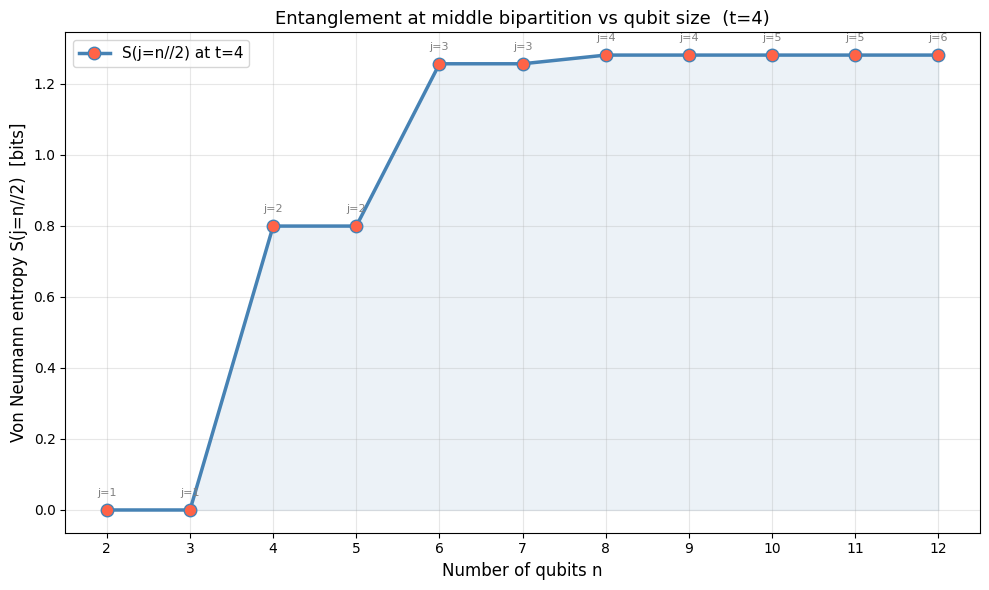

In [14]:
qubit_sizes  = list(range(2, 13))

t_fixed  = 4
builder  = lambda n: quantum_random_walk.construct_walk(n, t_fixed)
entropy.plot_entropy_vs_n(qubit_sizes, builder, t_fixed)

n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=1.00000
n= 5  j=2  S=1.00000
n= 6  j=3  S=1.00000
n= 7  j=3  S=1.00000
n= 8  j=4  S=1.00000
n= 9  j=4  S=1.00000
n=10  j=5  S=1.00000
n=11  j=5  S=1.00000
n=12  j=6  S=1.00000
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.81128
n= 5  j=2  S=0.81128
n= 6  j=3  S=1.35458
n= 7  j=3  S=1.35458
n= 8  j=4  S=1.35458
n= 9  j=4  S=1.35458
n=10  j=5  S=1.35458
n=11  j=5  S=1.35458
n=12  j=6  S=1.35458
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.98870
n= 5  j=2  S=0.98870
n= 6  j=3  S=1.28461
n= 7  j=3  S=1.28461
n= 8  j=4  S=1.43700
n= 9  j=4  S=1.43700
n=10  j=5  S=1.43700
n=11  j=5  S=1.43700
n=12  j=6  S=1.43700
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.91282
n= 5  j=2  S=0.90476
n= 6  j=3  S=1.46779
n= 7  j=3  S=1.46779
n= 8  j=4  S=1.44592
n= 9  j=4  S=1.44592
n=10  j=5  S=1.48508
n=11  j=5  S=1.48508
n=12  j=6  S=1.48508
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.94093
n= 5  j=2  S=

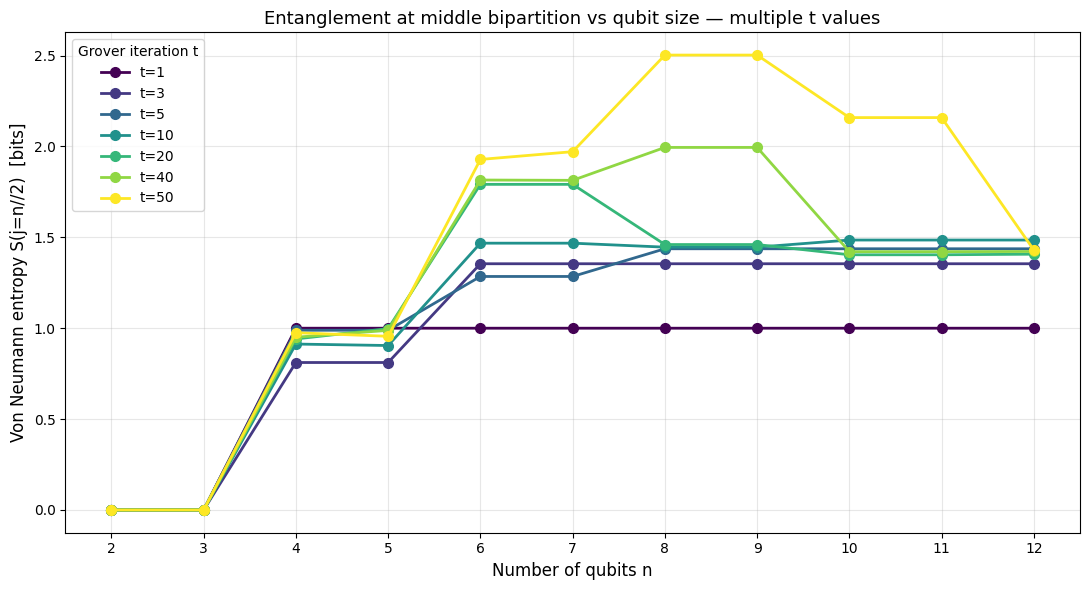

In [16]:
# Multiple t values — build one lambda per t
t_values      = [1, 3, 5, 10,20,40,50]
builder_per_t = [(t, lambda n, t=t: quantum_random_walk.construct_walk(n, t))
                 for t in t_values]
entropy.plot_entropy_vs_n_multi_t(qubit_sizes, builder_per_t)